# AML — Exploration Notebook

Interactive scratch space for the WRDS data pull, feature engineering, and ML model fitting.

**Pipeline flow:** §1 setup → §2/3 data → §4 features → §5 target/split → §6 fit & compare ML methods → §7 production forecast → §8 tangency optimizer (realized Σ). §9 is an appendix with model inspection and factor decompositions.

## 1. Setup & imports

In [3]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd()))

import os
os.environ['DYLD_LIBRARY_PATH'] = '/opt/homebrew/opt/libomp/lib'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({
    "axes.grid": False,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": False,
    "axes.spines.bottom": True,
})
import statsmodels.api as sm
import xgboost as xgb
import yfinance as yf

from pipeline import (
    CONFIG,
    wrds_connect,
    pull_crsp_msf, pull_crsp_dsf, pull_yfinance_daily,
    pull_compustat_funda, pull_ccm_link,
    merge_crsp_compustat, build_universe,
    fetch_ff5, merge_with_factors,
    build_features, FEATURE_COLS, FEATURE_DICT, feature_dictionary_df,
    get_all_feature_cols,
    make_target, train_val_test_split,
    fit_capm, fit_ff5, fit_elastic_net, fit_ridge, fit_xgboost,
    oos_r2_zero_benchmark, oos_r2_vs_historical_mean,
    rolling_oos_backtest, summarize_rolling, diebold_mariano,
    estimate_covariance, realized_covariance, tangency_portfolio,
)

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)
print(f"Python: {sys.executable}")

Python: /Users/Peter.W/venvs/aml/bin/python


## Portfolio under analysis

In [4]:
portfolio = {
    "Apple":             "AAPL",
    "JPMorgan Chase":    "JPM",
    "Exxon Mobil":       "XOM",
    "Johnson & Johnson": "JNJ",
    "Procter & Gamble":  "PG",
}
ticker_to_name = {t: n for n, t in portfolio.items()}

print(f"Portfolio: {len(portfolio)} stocks")
for name, tkr in portfolio.items():
    print(f"  {tkr:<6} {name}")

Portfolio: 5 stocks
  AAPL   Apple
  JPM    JPMorgan Chase
  XOM    Exxon Mobil
  JNJ    Johnson & Johnson
  PG     Procter & Gamble


## Date configuration

In [5]:
DATA_START = "1975-01-01"   # 50+ years of WRDS history
DATA_END   = "2026-04-30"   # latest available CRSP month-end (WRDS lag ~2 weeks)
TRAIN_END  = "2014-12-31"   # 40 years training
VAL_END    = "2019-12-31"   # 5 years validation
                            # test:  2020-01 -> 2026-04   (>6 years)

def _months(a, b):
    a, b = pd.Timestamp(a), pd.Timestamp(b)
    return (b.year - a.year) * 12 + (b.month - a.month) + 1

print(f"WRDS pull:    {DATA_START} -> {DATA_END}    ({_months(DATA_START, DATA_END)} months)")
print(f"  Train:      {DATA_START} -> {TRAIN_END}    ({_months(DATA_START, TRAIN_END)} months)")
print(f"  Validation: {TRAIN_END}+1mo -> {VAL_END}     ({_months(TRAIN_END, VAL_END) - 1} months)")
print(f"  Test:       {VAL_END}+1mo -> {DATA_END}      ({_months(VAL_END, DATA_END) - 1} months)")


WRDS pull:    1975-01-01 -> 2026-04-30    (616 months)
  Train:      1975-01-01 -> 2014-12-31    (480 months)
  Validation: 2014-12-31+1mo -> 2019-12-31     (60 months)
  Test:       2019-12-31+1mo -> 2026-04-30      (76 months)


## 2. Quick resume from cache

In [17]:
panel_path = CONFIG.cache_dir / "panel.parquet"
if panel_path.exists():
    panel = pd.read_parquet(panel_path)
    print(f"Loaded cached panel: {panel.shape}")
    print(f"  Date range in cache: {panel['date'].min().date()} -> {panel['date'].max().date()}")
else:
    print(f"No cache at {panel_path}. Run section 3 below to pull from WRDS first.")

ff5 = fetch_ff5()
print(f"FF5: {ff5.index.min().date()} -> {ff5.index.max().date()} (n={len(ff5)})")

Loaded cached panel: (2902303, 47)
  Date range in cache: 1975-01-31 -> 2024-12-31
FF5: 1963-07-31 -> 2026-03-31 (n=753)


---

## 3. Full WRDS pull (first-time setup or after changing dates)

### 3.1 Open a WRDS connection

In [6]:
conn = wrds_connect()

16:00:34 [INFO] Connecting to WRDS as cw3655...
Loading library list...
Done


### 3.2 CRSP monthly returns

In [7]:
crsp = pull_crsp_msf(conn, DATA_START, DATA_END)
print(crsp.shape); crsp.head()

16:00:35 [INFO] Pulling CRSP MSF (this can take a few minutes)...
16:01:16 [INFO]   CRSP MSF: 3,035,886 rows | 24,534 permnos | 1975-01-31 -> 2024-12-31
(3035886, 16)


,permno,date,ret,retx,prc,shrout,vol,shrcd,exchcd,ticker,comnam,siccd,dlret,dlstcd,ret_adj,mcap
0,10000,1986-01-31,<NA>,<NA>,-4.375,3680.0,1771.0,10,3,OMFGA,OPTIMUM MANUFACTURING INC,3990,<NA>,<NA>,<NA>,16100000.0
1,10000,1986-02-28,-0.257143,-0.257143,-3.25,3680.0,828.0,10,3,OMFGA,OPTIMUM MANUFACTURING INC,3990,<NA>,<NA>,-0.257143,11960000.0
2,10000,1986-03-31,0.365385,0.365385,-4.4375,3680.0,1078.0,10,3,OMFGA,OPTIMUM MANUFACTURING INC,3990,<NA>,<NA>,0.365385,16330000.0
3,10000,1986-04-30,-0.098592,-0.098592,-4.0,3793.0,957.0,10,3,OMFGA,OPTIMUM MANUFACTURING INC,3990,<NA>,<NA>,-0.098592,15172000.0
4,10000,1986-05-30,-0.222656,-0.222656,-3.10938,3793.0,1074.0,10,3,OMFGA,OPTIMUM MANUFACTURING INC,3990,<NA>,<NA>,-0.222656,11793878.34


### 3.3 Compustat annual fundamentals

In [8]:
comp = pull_compustat_funda(conn, DATA_START, DATA_END)
print(comp.shape); comp.head()

16:01:16 [INFO] Pulling Compustat funda...
16:01:35 [INFO]   Compustat funda: 534,716 rows | 46,054 gvkeys
(534716, 23)


,gvkey,datadate,fyear,at,lt,ceq,seq,ib,ni,oibdp,sale,revt,cogs,xsga,capx,dp,dvp,dvc,txdb,itcb,pstkrv,pstkl,pstk
0,001000,1975-12-31,1975,23.905,11.596,10.24,12.309,2.284,2.284,6.364,51.192,51.192,35.237,9.591,3.109,1.029,0.124,0.0,0.78,0.0,2.069,2.069,2.069
1,001000,1976-12-31,1976,38.586,22.911,14.106,15.675,3.434,3.434,8.741,66.414,66.414,45.277,12.396,7.023,1.598,0.094,0.0,1.421,0.0,1.569,1.569,1.569
2,001000,1977-12-31,1977,44.025,28.149,15.876,15.876,1.928,1.928,6.01,77.946,77.946,56.959,14.977,3.478,2.507,0.094,0.222,1.797,0.0,0.0,0.0,0.0
3,001001,1978-12-31,1978,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
4,001001,1979-12-31,1979,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>


### 3.4 CCM link table + merge

In [9]:
link = pull_ccm_link(conn)
print(link.shape); link.head()

16:01:35 [INFO] Pulling CCM link table...
(33324, 6)


,gvkey,permno,linkdt,linkenddt,linktype,linkprim
0,001000,25881.0,1970-11-13,1978-06-30,LU,P
1,001001,10015.0,1983-09-20,1986-07-31,LU,P
2,001002,10023.0,1972-12-14,1973-06-05,LC,C
3,001003,10031.0,1983-12-07,1989-08-16,LU,C
4,001004,54594.0,1972-04-24,2026-05-11,LU,P


In [10]:
panel = merge_crsp_compustat(crsp, comp, link)
panel = build_universe(panel, kind="top1000_mcap")
print(panel.shape); panel.head()

16:01:42 [INFO]   Merged panel: 2,902,303 rows
(2902303, 47)


,permno,date,ret,retx,prc,shrout,vol,shrcd,exchcd,ticker,comnam,siccd,dlret,dlstcd,ret_adj,mcap,gvkey,linkdt,linkenddt,linktype,...,ib,ni,oibdp,sale,revt,cogs,xsga,capx,dp,dvp,dvc,txdb,itcb,pstkrv,pstkl,pstk,available_date,mcap_lag1,mcap_rank,in_universe
588016,10000,1986-01-31,<NA>,<NA>,-4.375,3680.0,1771.0,10,3,OMFGA,OPTIMUM MANUFACTURING INC,3990,<NA>,<NA>,<NA>,16100000.0,013007,1986-01-07,1987-06-30,LU,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,1985-06-30,<NA>,<NA>,<NA>
594550,10000,1986-02-28,-0.257143,-0.257143,-3.25,3680.0,828.0,10,3,OMFGA,OPTIMUM MANUFACTURING INC,3990,<NA>,<NA>,-0.257143,11960000.0,013007,1986-01-07,1987-06-30,LU,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,1985-06-30,16100000.0,3610.0,False
601187,10000,1986-03-31,0.365385,0.365385,-4.4375,3680.0,1078.0,10,3,OMFGA,OPTIMUM MANUFACTURING INC,3990,<NA>,<NA>,0.365385,16330000.0,013007,1986-01-07,1987-06-30,LU,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,1985-06-30,11960000.0,3934.0,False
601669,10000,1986-04-30,-0.098592,-0.098592,-4.0,3793.0,957.0,10,3,OMFGA,OPTIMUM MANUFACTURING INC,3990,<NA>,<NA>,-0.098592,15172000.0,013007,1986-01-07,1987-06-30,LU,...,-0.511,-0.511,-0.373,0.354,0.354,0.361,0.366,0.026,0.046,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1986-04-30,16330000.0,3694.0,False
606903,10000,1986-05-30,-0.222656,-0.222656,-3.10938,3793.0,1074.0,10,3,OMFGA,OPTIMUM MANUFACTURING INC,3990,<NA>,<NA>,-0.222656,11793878.34,013007,1986-01-07,1987-06-30,LU,...,-0.511,-0.511,-0.373,0.354,0.354,0.361,0.366,0.026,0.046,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1986-04-30,15172000.0,3798.0,False


### 3.5 Inspect the panel

In [11]:
miss = panel.isna().mean().sort_values(ascending=False)
miss[miss > 0]

dlret             0.999260
dlstcd            0.997939
xsga              0.201982
itcb              0.159506
txdb              0.141960
capx              0.120566
dp                0.089786
oibdp             0.068941
vol               0.064546
sale              0.064018
revt              0.064018
cogs              0.064007
dvc               0.063207
dvp               0.063055
ni                0.061814
ib                0.061810
lt                0.061712
pstkl             0.060127
pstkrv            0.060119
pstk              0.059834
ceq               0.059640
seq               0.059426
at                0.059300
fyear             0.039531
available_date    0.039363
datadate          0.039363
mcap_lag1         0.011068
mcap_rank         0.011068
in_universe       0.011068
ret               0.009621
retx              0.009621
ret_adj           0.009620
prc               0.003220
mcap              0.003220
ticker            0.001441
dtype: float64

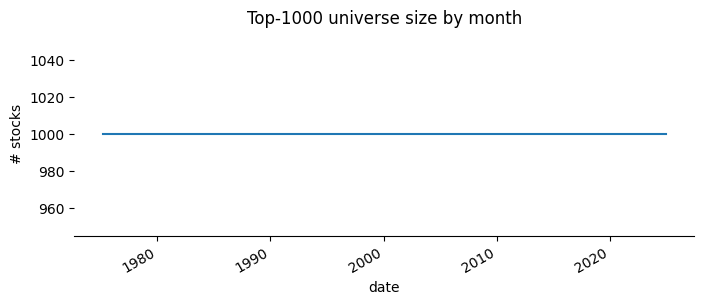

In [12]:
uni_size = panel[panel["in_universe"]].groupby("date")["permno"].nunique()
ax = uni_size.plot(figsize=(8, 3), title="Top-1000 universe size by month")
ax.set_ylabel("# stocks"); ax.grid(False)

### 3.6 Cache the panel

**Don't close `conn`** — §8 needs it for the daily-data pull.

In [13]:
CONFIG.cache_dir.mkdir(parents=True, exist_ok=True)
panel.to_parquet(CONFIG.cache_dir / "panel.parquet")
print(f"Cached -> {CONFIG.cache_dir / 'panel.parquet'}")

Cached -> cache/panel.parquet


---

## 4. Feature engineering

### 4.0 Feature dictionary

In [14]:
import importlib, pipeline
importlib.reload(pipeline)
from pipeline import (
    feature_dictionary_df, FEATURE_DICT, FEATURE_COLS,
    build_features, get_all_feature_cols,
    pull_crsp_dsf, pull_yfinance_daily, realized_covariance,
    merge_with_factors,
    make_target, train_val_test_split,
    fit_capm, fit_ff5, fit_elastic_net, fit_ridge, fit_xgboost,
    oos_r2_zero_benchmark, oos_r2_vs_historical_mean,
    rolling_oos_backtest, summarize_rolling, diebold_mariano,
    tangency_portfolio,
)

feat_dict_df = feature_dictionary_df()
feat_dict_df

,feature,name,category,formula,source,intuition,expected_sign,reference
0,size,Market capitalization (log),price,log(|prc| × shrout),CRSP,Smaller firms tend to earn higher average retu...,−,Banz (1981); Fama-French SMB (1993)
1,mom_1,Short-term reversal (1-month),price,ret_{t},CRSP,Last month's return reverses next month — liqu...,−,Jegadeesh (1990)
2,mom_12_2,"Momentum (12-2, skip-month)",price,"cumret(ret_{t-12}, …, ret_{t-2})",CRSP,Stocks that outperformed over past year (exclu...,+,Jegadeesh-Titman (1993); Carhart (1997)
3,mom_36_13,Long-term reversal (36-13),price,"cumret(ret_{t-36}, …, ret_{t-13})",CRSP,Past long-horizon winners tend to underperform...,−,DeBondt-Thaler (1985)
4,vol_12,Return volatility (12-month),price,"std(ret_{t-12}, …, ret_{t-1})",CRSP,Low-volatility stocks earn higher risk-adjuste...,−,"Ang, Hodrick, Xing, Zhang (2006)"
5,turnover,Share turnover,price,vol_{t} / shrout_{t},CRSP,Liquidity / attention proxy. Higher turnover a...,−,"Datar, Naik, Radcliffe (1998)"
6,mom_6_2,Medium-term momentum (6-2),price,"cumret(ret_{t-6}, …, ret_{t-2})",CRSP,Shorter-horizon momentum complements 12-2 mome...,+,Jegadeesh-Titman (1993)
7,maxret,Maximum monthly return (12-mo),price,"max(ret_{t-12}, …, ret_{t-1})",CRSP,Lottery-like stocks (high max return) underper...,−,"Bali, Cakici, Whitelaw (2011)"
8,nsi,Net share issuance (12-mo),price,log(shrout_{t} / shrout_{t-12}),CRSP,Firms that issue shares (positive nsi) tend to...,−,Pontiff-Woodgate (2008); Daniel-Titman (2006)
9,beta,CAPM beta (36-mo rolling),price,"Cov(r_i, Mkt-RF) / Var(Mkt-RF), 36-month rolli...",CRSP + Ken French,High-beta stocks have lower risk-adjusted retu...,−,Frazzini-Pedersen (2014); Ang-Hodrick-Xing-Zha...


In [15]:
feat_dict_df.to_csv("feature_dictionary.csv", index=False)
print("Saved -> feature_dictionary.csv")

Saved -> feature_dictionary.csv


### 4.1 Build features

In [18]:
features = build_features(panel, ff5=ff5, with_industry=True)
print(f"Features panel shape: {features.shape}")

ALL_COLS = get_all_feature_cols(features)
print(f"Total feature columns: {len(ALL_COLS)}")
print(f"  Firm characteristics ({len(FEATURE_COLS)}): {FEATURE_COLS}")
industry_cols = [c for c in ALL_COLS if c.startswith('sic_')]
print(f"  Industry dummies ({len(industry_cols)}): {industry_cols[:8]}...")

16:03:19 [INFO]   build_features: added 88 SIC2 industry dummies
16:03:19 [INFO] Features built: 17 firm chars × 2,902,303 rows
16:03:19 [INFO]   Firm-char columns: ['size', 'mom_1', 'mom_12_2', 'mom_36_13', 'vol_12', 'turnover', 'mom_6_2', 'maxret', 'nsi', 'beta', 'age', 'bm', 'ep', 'profit', 'leverage', 'invest', 'ind_mom']
Features panel shape: (2902303, 153)
Total feature columns: 105
  Firm characteristics (17): ['size', 'mom_1', 'mom_12_2', 'mom_36_13', 'vol_12', 'turnover', 'mom_6_2', 'maxret', 'nsi', 'beta', 'age', 'bm', 'ep', 'profit', 'leverage', 'invest', 'ind_mom']
  Industry dummies (88): ['sic_0', 'sic_1', 'sic_10', 'sic_11', 'sic_12', 'sic_13', 'sic_14', 'sic_15']...


### 4.2 Sanity checks

In [19]:
features[FEATURE_COLS].describe().T[["min", "max", "mean", "std"]].round(3)

,min,max,mean,std
size,-0.999727,1.0,0.000207,0.57642
mom_1,-0.999724,1.0,0.000207,0.574499
mom_12_2,-0.999698,1.0,0.000203,0.549723
mom_36_13,-0.999608,1.0,0.000194,0.496415
vol_12,-0.999697,1.0,0.000203,0.546985
turnover,-0.999726,1.0,0.000207,0.558407
mom_6_2,-0.999714,1.0,0.000205,0.563609
maxret,-0.999696,1.0,0.000203,0.546984
nsi,-0.999698,1.0,0.000203,0.548045
beta,-0.999698,1.0,0.000203,0.54951


In [20]:
features[FEATURE_COLS].corr().round(2)

,size,mom_1,mom_12_2,mom_36_13,vol_12,turnover,mom_6_2,maxret,nsi,beta,age,bm,ep,profit,leverage,invest,ind_mom
size,1.00,0.12,0.27,0.29,-0.39,0.32,0.21,-0.31,0.04,0.09,0.27,-0.28,0.27,0.37,0.08,0.15,0.08
mom_1,0.12,1.00,0.06,0.03,-0.06,0.07,0.04,0.02,-0.02,-0.02,0.04,-0.09,0.02,0.06,0.02,-0.01,0.03
mom_12_2,0.27,0.06,1.00,0.05,-0.13,0.07,0.63,0.09,0.09,-0.04,0.09,-0.28,0.06,0.15,0.05,0.01,0.27
mom_36_13,0.29,0.03,0.05,1.00,-0.23,0.06,0.03,-0.21,0.10,-0.02,0.07,-0.20,0.30,0.29,-0.00,0.31,0.02
vol_12,-0.39,-0.06,-0.13,-0.23,1.00,0.25,-0.09,0.89,0.18,0.41,-0.25,-0.10,-0.43,-0.25,-0.16,-0.03,-0.04
turnover,0.32,0.07,0.07,0.06,0.25,1.00,0.04,0.21,0.13,0.31,-0.05,-0.24,-0.09,0.10,-0.09,0.12,0.04
mom_6_2,0.21,0.04,0.63,0.03,-0.09,0.04,1.00,0.08,0.02,-0.03,0.07,-0.20,0.03,0.10,0.04,-0.02,0.18
maxret,-0.31,0.02,0.09,-0.21,0.89,0.21,0.08,1.00,0.17,0.34,-0.21,-0.16,-0.39,-0.21,-0.13,-0.04,0.02
nsi,0.04,-0.02,0.09,0.10,0.18,0.13,0.02,0.17,1.00,0.12,-0.12,-0.26,-0.18,-0.11,-0.01,0.17,0.03
beta,0.09,-0.02,-0.04,-0.02,0.41,0.31,-0.03,0.34,0.12,1.00,-0.07,-0.12,-0.15,-0.01,-0.10,0.05,-0.02


---

## 5. Build target + train/val/test split

In [21]:
fwt = make_target(features, kind="excess_rf", rf=ff5["RF"])
print(f"Panel with target: {fwt.shape}")
print(f"Non-null y: {fwt['y'].notna().sum():,}")
print(f"\nRaw y summary:")
print(fwt[["y"]].dropna().describe().T.round(4))

# Winsorize y at ±50%/month — handles thinly-traded extreme outliers
WINSOR_BOUND = 0.50
n_clipped = ((fwt["y"] < -WINSOR_BOUND) | (fwt["y"] > WINSOR_BOUND)).sum()
fwt["y"] = fwt["y"].clip(-WINSOR_BOUND, WINSOR_BOUND)
print(f"\nWinsorized y at ±{WINSOR_BOUND*100:.0f}% — {n_clipped} observations clipped")

Panel with target: (2902303, 154)
Non-null y: 2,869,065

Raw y summary:
       count    mean     std     min    25%     50%     75%      max
y  2869065.0  0.0087  0.1932 -1.0131 -0.072 -0.0035  0.0704  26.5794

Winsorized y at ±50% — 55740 observations clipped


In [22]:
X_tr, y_tr, X_va, y_va, X_te, y_te = train_val_test_split(
    fwt,
    train_end=TRAIN_END,
    val_end=VAL_END,
    test_end=DATA_END,
    feature_cols=ALL_COLS,
)
print(f"Train: X={X_tr.shape}, y={y_tr.shape}, mean(y)={y_tr.mean():.4f}, std(y)={y_tr.std():.4f}")
print(f"Val:   X={X_va.shape}, y={y_va.shape}, mean(y)={y_va.mean():.4f}, std(y)={y_va.std():.4f}")
print(f"Test:  X={X_te.shape}, y={y_te.shape}, mean(y)={y_te.mean():.4f}, std(y)={y_te.std():.4f}")

16:03:59 [INFO] Split sizes: train=477,091, val=59,773, test=58,850 (features=105)
Train: X=(477091, 105), y=(477091,), mean(y)=0.0078, std(y)=0.1038
Val:   X=(59773, 105), y=(59773,), mean(y)=0.0079, std(y)=0.0874
Test:  X=(58850, 105), y=(58850,), mean(y)=0.0077, std(y)=0.1157


---

## 6. Fit ML models — three to compare

1. **ElasticNet** — linear with mixed L1/L2 penalty.
2. **Ridge** — pure L2; cannot zero out coefs (all features stay active).
3. **XGBoost** — gradient-boosted trees; captures nonlinear interactions.

Fit all three, compare OOS R² in §6.4, pick the best in §6.5.

### 6.1 ElasticNet

In [23]:
model_enet = fit_elastic_net(X_tr, y_tr)
print(f"\nChosen alpha    = {model_enet.alpha_:.4g}")
print(f"Chosen l1_ratio = {model_enet.l1_ratio_:.2f}")
print(f"Nonzero coefs   = {int((model_enet.coef_ != 0).sum())}/{len(ALL_COLS)}")

16:04:03 [INFO] Fitting ElasticNet on 477,091 obs × 105 features...
16:04:20 [INFO]   Chosen: alpha=0.01096, l1_ratio=0.10, nonzero coefs=0

Chosen alpha    = 0.01096
Chosen l1_ratio = 0.10
Nonzero coefs   = 0/105


### 6.2 Ridge

In [24]:
model_ridge = fit_ridge(X_tr, y_tr)
print(f"\nChosen alpha   = {model_ridge.alpha_:.4g}")
print(f"|coef| max     = {np.abs(model_ridge.coef_).max():.4g}")
print(f"|coef| mean    = {np.abs(model_ridge.coef_).mean():.4g}")
print(f"Nonzero coefs  = {int((model_ridge.coef_ != 0).sum())}/{len(ALL_COLS)} (Ridge keeps all)")

16:04:20 [INFO] Fitting Ridge on 477,091 obs × 105 features...


16:05:40 [INFO]   Chosen alpha=100, |coef|_max=0.01944, |coef|_min nonzero=7.077e-06

Chosen alpha   = 100
|coef| max     = 0.01944
|coef| mean    = 0.002186
Nonzero coefs  = 92/105 (Ridge keeps all)


### 6.3 XGBoost

Gradient-boosted trees with early stopping on the validation set. Requires `pip install xgboost` (in the `aml` venv) if not already installed.

In [25]:
model_xgb = fit_xgboost(
    X_tr, y_tr,
    X_val=X_va, y_val=y_va,
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    early_stopping_rounds=20,
)
print(f"\nBest iteration: {model_xgb.best_iteration} / {model_xgb.n_estimators}")

16:05:41 [INFO] Fitting XGBoost on 477,091 obs × 105 features (max_estimators=500, max_depth=4, early_stopping=20)...


16:05:43 [INFO]   Best iteration: 6 of 500

Best iteration: 6 / 500


In [26]:
# Top-15 feature importances (gain-based)
imp = pd.Series(model_xgb.feature_importances_, index=ALL_COLS).sort_values(ascending=False)
print("Top-15 features by XGBoost gain importance:\n")
print(imp.head(15).round(4))

Top-15 features by XGBoost gain importance:

age         0.1096
invest      0.0849
beta        0.0838
leverage    0.0674
mom_12_2    0.0611
profit      0.0532
mom_6_2     0.0488
size        0.0487
mom_1       0.0458
maxret      0.0454
bm          0.0442
ep          0.0435
vol_12      0.0435
turnover    0.0425
ind_mom     0.0314
dtype: float32


### 6.4 Side-by-side comparison

Headline metric is **OOS R² (zero benchmark)** — GKX-comparable. Historical-mean version included for reference.

In [27]:
results = []
model_dict = {"ElasticNet": model_enet, "Ridge": model_ridge, "XGBoost": model_xgb}
for name, model in model_dict.items():
    y_pred_m = model.predict(X_te)
    r2_zero  = oos_r2_zero_benchmark(y_te, y_pred_m)
    y_hist   = np.full_like(y_te, y_tr.mean())
    r2_hist  = oos_r2_vs_historical_mean(
        pd.Series(y_te), pd.Series(y_pred_m), pd.Series(y_hist)
    )
    results.append({
        "model":            name,
        "OOS R² (zero, %)": round(r2_zero * 100, 4),
        "OOS R² (hist, %)": round(r2_hist * 100, 4),
    })
comparison = pd.DataFrame(results).set_index("model")
print("Model comparison (test set OOS R²):\n")
print(comparison)

Model comparison (test set OOS R²):

            OOS R² (zero, %)  OOS R² (hist, %)
model                                         
ElasticNet            0.4451            0.0000
Ridge                 0.3621           -0.0833
XGBoost               0.4674            0.0224


### 6.5 Pick the best ML method

Auto-select the model with highest zero-benchmark OOS R². Override manually if you prefer one for methodological reasons (e.g., reviewer asks for the linear ML representative — pick Ridge).

The chosen model feeds the production forecast (§7) and the tangency optimizer (§8).

In [28]:
# Single-split best — will be revisited in §6.6 walk-forward
best_name_single = comparison["OOS R² (zero, %)"].idxmax()
print(f"Single-split best: {best_name_single}")
print(f"  OOS R² (zero): {comparison.loc[best_name_single, 'OOS R² (zero, %)']:.4f}%")
print(f"  OOS R² (hist): {comparison.loc[best_name_single, 'OOS R² (hist, %)']:.4f}%")


Single-split best: XGBoost
  OOS R² (zero): 0.4674%
  OOS R² (hist): 0.0224%


### 6.6 Walk-forward backtest

Annual refit. For each test year *y*: train on years [y − train_years − val_years, y − val_years − 1], validate on years [y − val_years, y − 1] (used for XGBoost early stopping), predict each month of *y*. Walk forward, repeat.

**With 5 years of data** (2020–2024), `train_years=2, val_years=1` gives test years **2023 and 2024** — only 2 OOS observations. Tight but workable; the *pooled* R² across both years is the headline. With 10+ years you'd get 5+ test years and a richer comparison.

**Pooled R²** is the GKX-style headline; **per-year R²** and **hit rate** show whether the result is robust or driven by one lucky year.

In [29]:
TRAIN_YEARS = 10
VAL_YEARS   = 1
BACKTEST_TEST_START = "2000-01-01"   # 25+ years of OOS test data (enabled by 50-yr pull)
BACKTEST_TEST_END   = DATA_END

rolling_results = {}
for name, fit_fn in [
    ("ElasticNet", fit_elastic_net),
    ("Ridge",      fit_ridge),
    ("XGBoost",    fit_xgboost),
]:
    print(f"\n=== {name} ===")
    rolling_results[name] = rolling_oos_backtest(
        fwt, ALL_COLS, fit_fn,
        train_years=TRAIN_YEARS,
        val_years=VAL_YEARS,
        test_start=BACKTEST_TEST_START,
        test_end=BACKTEST_TEST_END,
    )



=== ElasticNet ===
16:06:00 [INFO] Rolling backtest: fit_elastic_net | train_years=10, val_years=1, test years 2000-2026 (27 years)
16:06:00 [INFO] Fitting ElasticNet on 119,570 obs × 105 features...
16:06:01 [INFO]   Chosen: alpha=0.0005574, l1_ratio=0.95, nonzero coefs=2
16:06:01 [INFO]   Year 2000: train=119,570, val=11,915, test=11,900, OOS R²=-0.531%
16:06:02 [INFO] Fitting ElasticNet on 119,540 obs × 105 features...
16:06:02 [INFO]   Chosen: alpha=0.0003729, l1_ratio=0.95, nonzero coefs=10
16:06:03 [INFO]   Year 2001: train=119,540, val=11,900, test=11,933, OOS R²=-2.159%
16:06:03 [INFO] Fitting ElasticNet on 119,469 obs × 105 features...
16:06:04 [INFO]   Chosen: alpha=0.001102, l1_ratio=0.10, nonzero coefs=23
16:06:04 [INFO]   Year 2002: train=119,469, val=11,933, test=11,968, OOS R²=-2.061%
16:06:05 [INFO] Fitting ElasticNet on 119,421 obs × 105 features...
16:06:06 [INFO]   Chosen: alpha=0.02206, l1_ratio=0.10, nonzero coefs=0
16:06:06 [INFO]   Year 2003: train=119,421, val=

In [30]:
rolling_summary = pd.DataFrame([
    {
        "model":         name,
        "pooled_R² (%)":   round(s["pooled_r2_zero"] * 100, 4),
        "hit_rate (%)":  round(s["hit_rate"] * 100, 1),
        "n_test_years":  s["n_test_years"],
        "n_obs":         s["n_observations"],
    }
    for name, s in [(n, summarize_rolling(r)) for n, r in rolling_results.items()]
]).set_index("model")
print("Walk-forward backtest summary:\n")
print(rolling_summary)


Walk-forward backtest summary:

            pooled_R² (%)  hit_rate (%)  n_test_years   n_obs
model                                                        
ElasticNet        -0.0039          60.0            25  297895
Ridge             -0.6934          44.0            25  297895
XGBoost           -0.0062          52.0            25  297895


In [31]:
yearly = pd.DataFrame({
    name: summarize_rolling(r)["yearly_r2"] * 100
    for name, r in rolling_results.items()
}).round(4)
yearly.index.name = "test_year"
print("Per-year OOS R² (%, zero benchmark):\n")
print(yearly)


Per-year OOS R² (%, zero benchmark):

           ElasticNet   Ridge  XGBoost
test_year                             
2000          -0.5306 -0.8501  -0.3654
2001          -2.1593 -3.5271  -1.4451
2002          -2.0614 -2.4744  -2.1230
2003           3.9457  2.4714   3.6287
2004           0.5390 -0.0115   0.8446
2005           1.4758  0.8272   1.6010
2006           0.7164 -0.9096   0.5240
2007          -2.8211 -5.2149  -1.5691
2008          -2.2682 -4.0264  -2.3102
2009           1.4350  1.3292   1.4743
2010          -0.4390 -1.3836  -0.4832
2011           0.1051 -0.7138  -0.6016
2012           1.5030  1.1753   1.9339
2013           3.4515  3.1304   4.6679
2014           1.1759  0.8673  -0.5721
2015          -1.8654 -3.0334  -1.8828
2016           3.4627  3.2528   2.6299
2017           3.0075  2.8987   3.0319
2018          -1.0287 -1.5970  -1.8641
2019           1.3628  0.8887   1.3620
2020           1.9742  1.9423   1.8344
2021           0.1329 -0.3186   0.0598
2022          -1.1433 -2.0

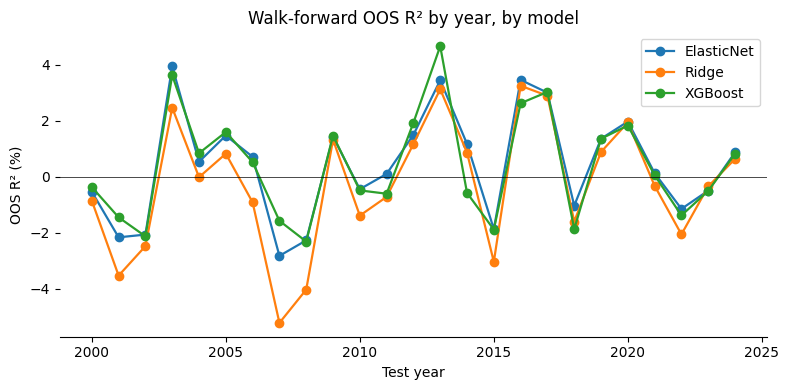

In [32]:
fig, ax = plt.subplots(figsize=(8, 4))
yearly.plot(marker="o", ax=ax, linewidth=1.6)
ax.axhline(0, color="black", linewidth=0.5)
ax.set_ylabel("OOS R² (%)")
ax.set_xlabel("Test year")
ax.set_title("Walk-forward OOS R² by year, by model")
ax.grid(False)
ax.legend()
plt.tight_layout()
plt.show()


### 6.7 Diebold-Mariano test — best vs others

Tests whether the difference in pooled squared error is statistically significant. Negative t-stat → first model has smaller errors.

**Caveat:** with only 2 test years, statistical power is modest. DM is more meaningful with 5+ test years.

In [33]:
best = rolling_summary["pooled_R² (%)"].idxmax()
others = [m for m in rolling_summary.index if m != best]

for other in others:
    aligned = rolling_results[best].merge(
        rolling_results[other][["date", "permno", "y_pred"]],
        on=["date", "permno"], suffixes=("", "_b"),
    )
    dm = diebold_mariano(
        aligned["y"].values,
        aligned["y_pred"].values,
        aligned["y_pred_b"].values,
    )
    print(f"{best} vs {other}:")
    print(f"  n={dm['n']:,}  mean(SSE_diff)={dm['mean_sse_diff']:.6f}  "
          f"t={dm['t_stat']:.3f}  p={dm['p_value']:.4f}")
    if dm['p_value'] < 0.10:
        better = best if dm['mean_sse_diff'] < 0 else other
        print(f"  ⇒ {better} significantly better (p<0.10)")
    else:
        print(f"  ⇒ no significant difference (p>=0.10)")
    print()


ElasticNet vs Ridge:
  n=297,895  mean(SSE_diff)=-0.000081  t=-27.731  p=0.0000
  ⇒ ElasticNet significantly better (p<0.10)

ElasticNet vs XGBoost:
  n=297,895  mean(SSE_diff)=-0.000000  t=-0.140  p=0.8889
  ⇒ no significant difference (p>=0.10)



### 6.8 Final model selection

Walk-forward pooled R² is the more reliable signal. If single-split and walk-forward agree, easy. If they disagree, trust walk-forward.

In [34]:
best_name_rolling = rolling_summary["pooled_R² (%)"].idxmax()

print(f"Single-split (§6.5) picks: {best_name_single}")
print(f"Walk-forward (§6.6) picks: {best_name_rolling}")

# Default: trust walk-forward. Override below if you want.
chosen_name  = best_name_rolling
chosen_model = model_dict[chosen_name]

# Manual override:
# chosen_name = "ElasticNet"
# chosen_model = model_dict[chosen_name]

print(f"\nFinal choice for §7-8: {chosen_name}")
print(f"  Walk-forward pooled R²: {rolling_summary.loc[chosen_name, 'pooled_R² (%)']:.4f}%")
print(f"  Walk-forward hit rate:  {rolling_summary.loc[chosen_name, 'hit_rate (%)']:.1f}%")
print(f"  Single-split R²:        {comparison.loc[chosen_name, 'OOS R² (zero, %)']:.4f}%")


Single-split (§6.5) picks: XGBoost
Walk-forward (§6.6) picks: ElasticNet

Final choice for §7-8: ElasticNet
  Walk-forward pooled R²: -0.0039%
  Walk-forward hit rate:  60.0%
  Single-split R²:        0.4451%


---

## 7. Production forecast

Refit the chosen model class on the **full available sample** (train + validation + test) and forecast next-month excess returns for the portfolio. No holdout — for live use, you want every drop of training data.

### 7.1 Train production model on all data

In [35]:
fit_df = fwt.dropna(subset=["y"]).query("in_universe").sort_values(["date", "permno"])
X_all = fit_df[ALL_COLS].values
y_all = fit_df["y"].values
print(f"Production training set: {X_all.shape[0]:,} obs × {X_all.shape[1]} features\n")

# Train ALL THREE production models on the full sample.
# The app lets the user switch between them in real time.
n_best = getattr(model_xgb, "best_iteration", 500) or 500

models_prod = {
    "ElasticNet": fit_elastic_net(X_all, y_all),
    "Ridge":      fit_ridge(X_all, y_all),
    "XGBoost":    fit_xgboost(
        X_all, y_all,
        n_estimators=n_best,
        max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
    ),
}

# The "chosen" one (highest walk-forward pooled R²) is what we default to,
# but the dict has all three for the app's selector.
model_prod = models_prod[chosen_name]

print(f"\nProduction models trained: {list(models_prod.keys())}")
print(f"Default (best by walk-forward): {chosen_name}")


Production training set: 595,714 obs × 105 features

16:11:35 [INFO] Fitting ElasticNet on 595,714 obs × 105 features...
16:12:06 [INFO]   Chosen: alpha=0.009555, l1_ratio=0.10, nonzero coefs=0
16:12:06 [INFO] Fitting Ridge on 595,714 obs × 105 features...
16:13:14 [INFO]   Chosen alpha=100, |coef|_max=0.01396, |coef|_min nonzero=7.231e-06
16:13:14 [INFO] Fitting XGBoost on 595,714 obs × 105 features (estimators=6, no early stopping)...

Production models trained: ['ElasticNet', 'Ridge', 'XGBoost']
Default (best by walk-forward): ElasticNet


### 7.2 Forecast next month for the portfolio

In [36]:
def forecast_for_subset(tickers, model, features_df, feature_cols, name_lookup=None):
    """Most-recent feature snapshot per ticker -> predicted next-month excess return."""
    latest = (
        features_df[features_df["in_universe"]]
          .sort_values(["ticker", "date"])
          .groupby("ticker")
          .tail(1)
    )
    sub = latest[latest["ticker"].isin(tickers)].set_index("ticker").reindex(tickers)
    missing = sub[sub[feature_cols].isna().any(axis=1)].index.tolist()
    if missing:
        print(f"Warning: missing features for {missing} — μ̂ will be unreliable")
    sub["mu_hat"] = model.predict(sub[feature_cols].fillna(0).values)
    sub["as_of"]  = sub["date"]
    if name_lookup:
        sub.insert(0, "company", sub.index.map(name_lookup))
    return sub[(["company"] if name_lookup else []) + ["as_of", "mu_hat"] + FEATURE_COLS]

fcast = forecast_for_subset(
    list(portfolio.values()),
    model_prod,
    features,
    feature_cols=ALL_COLS,
    name_lookup=ticker_to_name,
)
print(f"μ̂ forecast (using {chosen_name}, excess of risk-free rate, monthly horizon):")
print(fcast[["company", "as_of", "mu_hat"]].to_string())

μ̂ forecast (using ElasticNet, excess of risk-free rate, monthly horizon):
                  company      as_of    mu_hat
ticker                                        
AAPL                Apple 2024-12-31  0.007816
JPM        JPMorgan Chase 2024-12-31  0.007816
XOM           Exxon Mobil 2024-12-31  0.007816
JNJ     Johnson & Johnson 2024-12-31  0.007816
PG       Procter & Gamble 2024-12-31  0.007816


---

## 8. Tangency portfolio with realized covariance

Closed-form mean-variance optimal weights:

$$w^\star \;\propto\; \hat\Sigma^{-1} \, \hat\mu, \qquad \sum_i w_i^\star = 1$$

$\hat\mu$ from §7.2 (chosen ML model). $\hat\Sigma$ from realized covariance over past ~60 trading days of daily returns (Andersen-Bollerslev-Diebold-Labys 2003).

### 8.1 Pull daily returns for the portfolio stocks

In [37]:
# Daily returns from yfinance (no WRDS login needed)
port_tickers = list(portfolio.values())

daily_buffer_start = (pd.Timestamp(DATA_END) - pd.DateOffset(months=12)).strftime("%Y-%m-%d")
daily_wide = pull_yfinance_daily(port_tickers, daily_buffer_start, DATA_END)
print(f"Daily returns shape: {daily_wide.shape} (dates × tickers)")
daily_wide.tail()


16:13:25 [INFO] Pulling yfinance daily for 5 tickers (2025-04-30 -> 2026-04-30)...
16:13:26 [INFO]   yfinance: 250 dates × 5 tickers
Daily returns shape: (250, 5) (dates × tickers)


Ticker,AAPL,JPM,XOM,JNJ,PG
date,,,,,
2026-04-23,0.000952,-0.004249,0.006890,0.020124,0.020021
2026-04-24,-0.008668,-0.010940,-0.010762,-0.013657,0.024609
2026-04-27,-0.012728,0.010867,-0.004835,-0.009495,0.001485
2026-04-28,0.011584,-0.000578,0.015993,0.010872,0.005189
2026-04-29,-0.001995,-0.007064,0.027298,-0.001932,-0.018167


### 8.2 Realized covariance from past 60 trading days

In [38]:
Sigma = realized_covariance(daily_wide, window_days=60, horizon="monthly")
print("Realized covariance Σ (monthly horizon):")
print(Sigma.round(5))

16:13:26 [INFO] Realized covariance: 60 daily obs × 5 assets | horizon=monthly
Realized covariance Σ (monthly horizon):
Ticker     AAPL      JPM      XOM      JNJ       PG
Ticker                                             
AAPL    0.00524  0.00207 -0.00089  0.00020  0.00080
JPM     0.00207  0.00496 -0.00105 -0.00026 -0.00018
XOM    -0.00089 -0.00105  0.00752  0.00019 -0.00092
JNJ     0.00020 -0.00026  0.00019  0.00221  0.00150
PG      0.00080 -0.00018 -0.00092  0.00150  0.00387


In [39]:
vols = pd.Series(np.sqrt(np.diag(Sigma.values)), index=Sigma.index, name="monthly_vol")
print("Monthly volatility (annualized in parens):\n")
for t, v in vols.items():
    print(f"  {t:<6} {v*100:.2f}%   (annualized: {v*np.sqrt(12)*100:.1f}%)")

Monthly volatility (annualized in parens):

  AAPL   7.24%   (annualized: 25.1%)
  JPM    7.04%   (annualized: 24.4%)
  XOM    8.67%   (annualized: 30.0%)
  JNJ    4.70%   (annualized: 16.3%)
  PG     6.22%   (annualized: 21.6%)


In [40]:
stds = np.sqrt(np.diag(Sigma.values))
corr = Sigma.values / np.outer(stds, stds)
pd.DataFrame(corr, index=Sigma.index, columns=Sigma.columns).round(2)

Ticker,AAPL,JPM,XOM,JNJ,PG
Ticker,,,,,
AAPL,1.00,0.41,-0.14,0.06,0.18
JPM,0.41,1.00,-0.17,-0.08,-0.04
XOM,-0.14,-0.17,1.00,0.05,-0.17
JNJ,0.06,-0.08,0.05,1.00,0.51
PG,0.18,-0.04,-0.17,0.51,1.00


### 8.3 Compute tangency portfolio weights

In [41]:
mu_hat = fcast["mu_hat"].reindex(port_tickers).values
Sigma_ordered = Sigma.loc[port_tickers, port_tickers].values
w_star = tangency_portfolio(mu_hat, Sigma_ordered, rf=0.0)

result = pd.DataFrame({
    "company":  [ticker_to_name[t] for t in port_tickers],
    "ticker":   port_tickers,
    "mu_hat":   mu_hat,
    "weight":   w_star,
})
print(f"Tangency portfolio (μ̂ from {chosen_name}, Σ̂ from realized covariance):")
print(result.to_string(index=False))
print(f"\nSum of weights:  {w_star.sum():.4f}")
print(f"Long exposure:   {w_star[w_star > 0].sum():.4f}")
print(f"Short exposure:  {w_star[w_star < 0].sum():.4f}")

Tangency portfolio (μ̂ from ElasticNet, Σ̂ from realized covariance):
          company ticker   mu_hat   weight
            Apple   AAPL 0.007816 0.094940
   JPMorgan Chase    JPM 0.007816 0.222141
      Exxon Mobil    XOM 0.007816 0.184115
Johnson & Johnson    JNJ 0.007816 0.341493
 Procter & Gamble     PG 0.007816 0.157310

Sum of weights:  1.0000
Long exposure:   1.0000
Short exposure:  0.0000


In [42]:
exp_ret = float(w_star @ mu_hat)
port_var = float(w_star @ Sigma_ordered @ w_star)
port_vol = float(np.sqrt(port_var))
sharpe_m = exp_ret / port_vol if port_vol > 0 else np.nan

print(f"Expected monthly excess return:  {exp_ret*100:.3f}%")
print(f"Expected monthly volatility:     {port_vol*100:.3f}%")
print(f"Sharpe ratio (monthly):          {sharpe_m:.3f}")
print(f"Sharpe ratio (annualized × √12): {sharpe_m * np.sqrt(12):.3f}")

Expected monthly excess return:  0.782%
Expected monthly volatility:     3.141%
Sharpe ratio (monthly):          0.249
Sharpe ratio (annualized × √12): 0.862


---

## 9. Walk-forward backtest of the strategy vs. S&P 500

End-to-end performance test. For each month in the OOS window:
1. Take ML predictions $\hat\mu$ from §6.6 rolling backtest (chosen model).
2. Estimate $\hat\Sigma$ from the prior 60 trading days of yfinance daily returns.
3. Compute tangency weights $w^\star \propto \hat\Sigma^{-1}\hat\mu$.
4. Apply weights to the realized next-month excess return.
5. Compare cumulative wealth path against SPY (S&P 500 ETF) buy-and-hold.

This is the proper way to evaluate a portfolio strategy — model and Σ both refit at every rebalance, no look-ahead bias, full apples-to-apples vs the benchmark.

### 9.1 Pull daily returns for portfolio + SPY

In [43]:
# Backtest needs daily history covering [test_start − 60 trading days, test_end]
backtest_start = pd.Timestamp(BACKTEST_TEST_START)
backtest_end   = pd.Timestamp(BACKTEST_TEST_END)
buffer_start   = (backtest_start - pd.DateOffset(months=6)).strftime("%Y-%m-%d")

bt_tickers = port_tickers + ["SPY"]
daily_bt = pull_yfinance_daily(bt_tickers, buffer_start, backtest_end.strftime("%Y-%m-%d"))
print(f"Daily backtest data: {daily_bt.shape} (dates × tickers)")
daily_bt.tail()


16:13:26 [INFO] Pulling yfinance daily for 6 tickers (1999-07-01 -> 2026-04-30)...
16:13:28 [INFO]   yfinance: 6747 dates × 6 tickers
Daily backtest data: (6747, 6) (dates × tickers)


Ticker,AAPL,JPM,XOM,JNJ,PG,SPY
date,,,,,,
2026-04-23,0.000952,-0.004249,0.006890,0.020124,0.020021,-0.003881
2026-04-24,-0.008668,-0.010940,-0.010762,-0.013657,0.024609,0.007749
2026-04-27,-0.012728,0.010867,-0.004835,-0.009495,0.001485,0.001723
2026-04-28,0.011584,-0.000578,0.015993,0.010872,0.005189,-0.004866
2026-04-29,-0.001995,-0.007064,0.027298,-0.001932,-0.018167,-0.000155


### 9.2 Compute strategy returns month by month

Reuse the chosen model's rolling-backtest predictions (§6.6). Each rebalance date, estimate Σ from the past 60 daily observations, compute tangency weights, apply to realized excess returns.

In [44]:
# Filter rolling predictions to portfolio stocks
preds_chosen = rolling_results[chosen_name]
port_preds = preds_chosen[preds_chosen["ticker"].isin(port_tickers)].copy()

records = []
weights_history = []
eq_weight = np.ones(len(port_tickers)) / len(port_tickers)   # equal-weighted benchmark

for rebalance_dt in sorted(port_preds["date"].unique()):
    sub = port_preds[port_preds["date"] == rebalance_dt].set_index("ticker")
    if not all(t in sub.index for t in port_tickers):
        continue

    # Coerce to plain numpy float arrays
    mu       = sub.loc[port_tickers, "y_pred"].astype("float64").to_numpy()
    realized = sub.loc[port_tickers, "y"].astype("float64").to_numpy()

    rebalance_me = rebalance_dt + pd.offsets.MonthEnd(0)
    dw = daily_bt.loc[:rebalance_me, port_tickers].dropna().tail(60)
    if len(dw) < 30:
        continue
    Sigma_d = dw.cov().to_numpy() * 21

    try:
        w = tangency_portfolio(mu, Sigma_d, rf=0.0)
    except np.linalg.LinAlgError:
        continue

    strat_excess  = float(w @ realized)
    eq_excess     = float(eq_weight @ realized)   # equal-weighted benchmark return
    records.append({
        "rebalance":       rebalance_dt,
        "strategy_excess": strat_excess,
        "equal_excess":    eq_excess,
    })
    weights_history.append(pd.Series(w, index=port_tickers, name=rebalance_dt))

bt_df = pd.DataFrame(records).set_index("rebalance").sort_index()
weights_df = pd.DataFrame(weights_history)
print(f"Strategy: {len(bt_df)} months of OOS returns")
print(f"\nTangency weights (mean across months):")
print(weights_df.mean().round(4))
print(f"\nEqual-weight benchmark: {eq_weight.round(3)}")


Strategy: 298 months of OOS returns

Tangency weights (mean across months):
AAPL    0.0607
JPM     0.0523
XOM     0.1297
JNJ     0.4008
PG      0.3566
dtype: float64

Equal-weight benchmark: [0.2 0.2 0.2 0.2 0.2]


### 9.3 SPY benchmark — same months, excess of risk-free

In [45]:
# Monthly total returns from daily yfinance
monthly_bt = (1 + daily_bt).resample("ME").prod() - 1

spy_excess      = []
strat_total_ret = []
eq_total_ret    = []
for rebalance_dt in bt_df.index:
    rebalance_me = rebalance_dt + pd.offsets.MonthEnd(0)
    next_me      = rebalance_me + pd.offsets.MonthEnd(1)

    if next_me in monthly_bt.index and not pd.isna(monthly_bt.loc[next_me, "SPY"]):
        spy_total = monthly_bt.loc[next_me, "SPY"]
    else:
        spy_total = np.nan

    rf_next = ff5["RF"].get(next_me, np.nan)

    if pd.notna(spy_total) and pd.notna(rf_next):
        spy_excess.append(spy_total - rf_next)
    else:
        spy_excess.append(np.nan)

    if pd.notna(rf_next):
        strat_total_ret.append(bt_df.loc[rebalance_dt, "strategy_excess"] + rf_next)
        eq_total_ret.append(bt_df.loc[rebalance_dt, "equal_excess"] + rf_next)
    else:
        strat_total_ret.append(np.nan)
        eq_total_ret.append(np.nan)

bt_df["spy_excess"]     = spy_excess
bt_df["strategy_total"] = strat_total_ret
bt_df["equal_total"]    = eq_total_ret
bt_df["spy_total"]      = bt_df["spy_excess"] + ff5["RF"].reindex(
    [d + pd.offsets.MonthEnd(1) for d in bt_df.index]
).values

bt_df = bt_df.dropna(subset=["strategy_total", "equal_total", "spy_total"])
print(f"Aligned backtest: {len(bt_df)} months")
print(bt_df.head())


Aligned backtest: 298 months
            strategy_excess  equal_excess  spy_excess  strategy_total  equal_total  spy_total
rebalance                                                                                    
2000-01-31        -0.105043     -0.078999   -0.019526       -0.100743    -0.074699  -0.015226
2000-02-29        -0.021562      0.001756    0.092215       -0.016862     0.006456   0.096915
2000-03-31         0.012212      0.019844   -0.039721        0.016812     0.024444  -0.035121
2000-04-28        -0.030746     -0.013047   -0.020723       -0.025746    -0.008047  -0.016123
2000-05-31         0.007099      0.006307    0.015682        0.011099     0.010307   0.019682


### 9.4 Cumulative wealth and summary statistics

In [46]:
# Cumulative wealth ($1 starting)
strat_wealth = (1 + bt_df["strategy_total"]).cumprod()
eq_wealth    = (1 + bt_df["equal_total"]).cumprod()
spy_wealth   = (1 + bt_df["spy_total"]).cumprod()

def perf_stats(monthly_returns, label):
    r = monthly_returns.dropna()
    n = len(r)
    total_ret  = (1 + r).prod() - 1
    ann_ret    = (1 + r).prod() ** (12 / n) - 1
    ann_vol    = r.std() * np.sqrt(12)
    sharpe     = ann_ret / ann_vol if ann_vol > 0 else np.nan
    cum        = (1 + r).cumprod()
    drawdown   = cum / cum.cummax() - 1
    max_dd     = drawdown.min()
    return {
        "label":         label,
        "n_months":      n,
        "total_return":  total_ret,
        "ann_return":    ann_ret,
        "ann_vol":       ann_vol,
        "sharpe":        sharpe,
        "max_drawdown":  max_dd,
    }

stats = pd.DataFrame([
    perf_stats(bt_df["strategy_total"], f"Strategy ({chosen_name})"),
    perf_stats(bt_df["equal_total"],    "Equal-weighted (5 stocks)"),
    perf_stats(bt_df["spy_total"],      "SPY (S&P 500)"),
]).set_index("label")
print("Performance summary:\n")
print(stats.round(4))


Performance summary:

                           n_months  total_return  ann_return  ann_vol  sharpe  max_drawdown
label                                                                                       
Strategy (ElasticNet)           298        6.1765      0.0826   0.1479  0.5585       -0.3802
Equal-weighted (5 stocks)       298       26.0405      0.1420   0.1511  0.9398       -0.3352
SPY (S&P 500)                   298        5.2538      0.0766   0.1529  0.5011       -0.5078


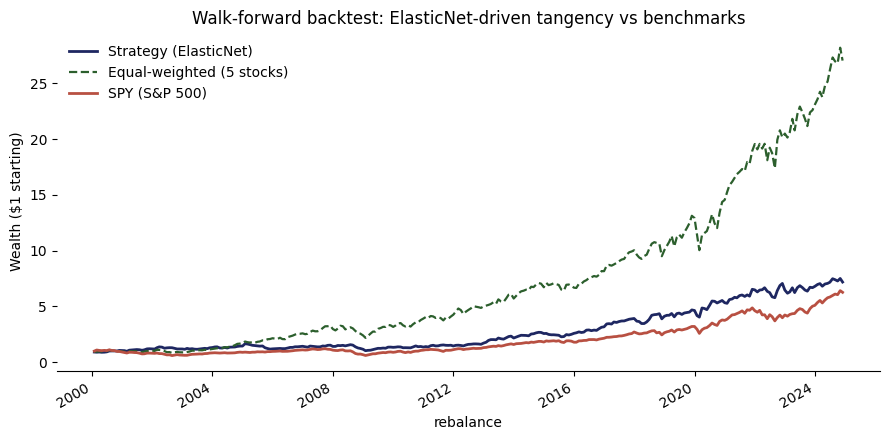

In [47]:
fig, ax = plt.subplots(figsize=(9, 4.5))
strat_wealth.plot(ax=ax, label=f"Strategy ({chosen_name})", linewidth=2,   color="#1E2761")
eq_wealth.plot(ax=ax,    label="Equal-weighted (5 stocks)", linewidth=1.6, color="#2C5F2D", linestyle="--")
spy_wealth.plot(ax=ax,   label="SPY (S&P 500)",             linewidth=2,   color="#B85042")
ax.set_ylabel("Wealth ($1 starting)")
ax.set_title(f"Walk-forward backtest: {chosen_name}-driven tangency vs benchmarks")
ax.legend(frameon=False)
ax.grid(False)
plt.tight_layout()
plt.show()


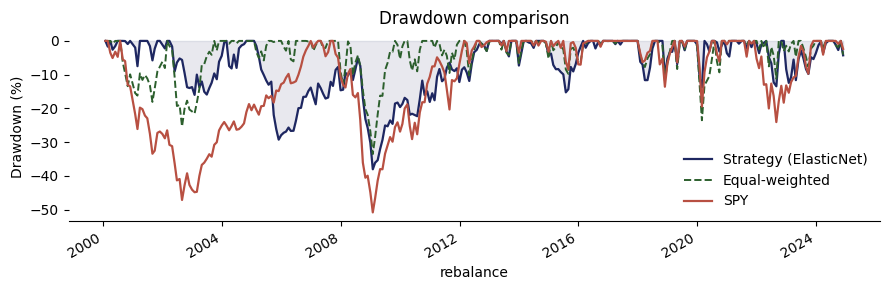

In [48]:
fig, ax = plt.subplots(figsize=(9, 3))
strat_dd = strat_wealth / strat_wealth.cummax() - 1
eq_dd    = eq_wealth    / eq_wealth.cummax()    - 1
spy_dd   = spy_wealth   / spy_wealth.cummax()   - 1
(strat_dd * 100).plot(ax=ax, label=f"Strategy ({chosen_name})", linewidth=1.6, color="#1E2761")
(eq_dd * 100).plot(ax=ax,    label="Equal-weighted",            linewidth=1.4, color="#2C5F2D", linestyle="--")
(spy_dd * 100).plot(ax=ax,   label="SPY",                       linewidth=1.6, color="#B85042")
ax.fill_between(strat_dd.index, strat_dd*100, 0, alpha=0.10, color="#1E2761")
ax.set_ylabel("Drawdown (%)")
ax.set_title("Drawdown comparison")
ax.legend(frameon=False)
ax.grid(False)
plt.tight_layout()
plt.show()


### 9.5 Weights drift over the backtest

How much does the optimal allocation move from month to month? Stable weights = the model's signal is consistent. Wildly oscillating weights = the model is reactive (or noisy).

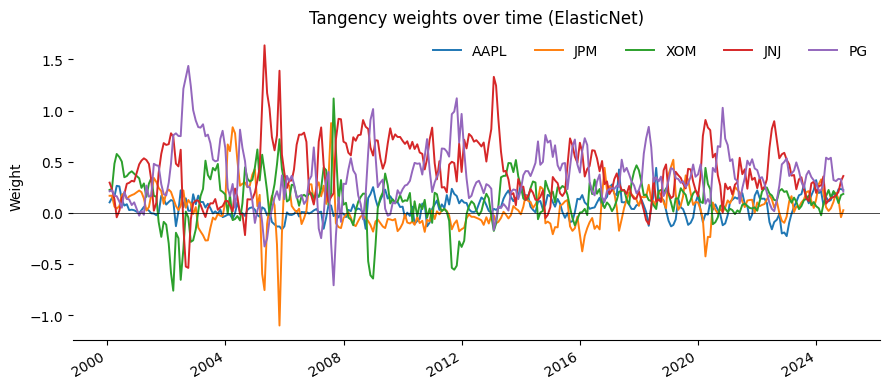


Weights summary across rebalances:
        mean     std     min     max
AAPL  0.0607  0.1030 -0.2279  0.4399
JPM   0.0523  0.2015 -1.1025  0.8780
XOM   0.1297  0.2237 -0.7617  1.1188
JNJ   0.4008  0.2937 -0.5387  1.6385
PG    0.3566  0.2786 -0.7088  1.4375


In [49]:
fig, ax = plt.subplots(figsize=(9, 4))
weights_df.plot(ax=ax, linewidth=1.4)
ax.axhline(0, color="black", linewidth=0.5)
ax.set_ylabel("Weight")
ax.set_title(f"Tangency weights over time ({chosen_name})")
ax.legend(frameon=False, ncol=len(port_tickers))
ax.grid(False)
plt.tight_layout()
plt.show()

print("\nWeights summary across rebalances:")
print(weights_df.describe().T[["mean", "std", "min", "max"]].round(4))


---

# Appendix

## 10. Inspection of the chosen model

Diagnostic material that supports the report but isn't part of the main forecast → optimize pipeline. Run if you want to characterize the chosen model's behavior in detail.

### 10.1 Reattach predictions to (date, permno, ticker)

In [50]:
test_df = (
    fwt[(fwt["date"] > VAL_END) & (fwt["date"] <= DATA_END)]
      .dropna(subset=["y"])
      .query("in_universe")
      .sort_values(["date", "permno"])
      .copy()
)
test_df["y_pred"] = chosen_model.predict(test_df[ALL_COLS])
test_df["err"]    = test_df["y"] - test_df["y_pred"]

print(f"Test predictions ({chosen_name}): {len(test_df):,} rows")
test_df[["date", "permno", "ticker", "y_pred", "y", "err"]].head()

Test predictions (ElasticNet): 58,850 rows


,date,permno,ticker,y_pred,y,err
3409,2020-01-31,10026,JJSF,0.007811,-0.03147,-0.039281
12676,2020-01-31,10104,ORCL,0.007811,-0.058207,-0.066018
13265,2020-01-31,10107,MSFT,0.007811,-0.046492,-0.054303
16639,2020-01-31,10138,TROW,0.007811,-0.117429,-0.12524
17996,2020-01-31,10145,HON,0.007811,-0.059796,-0.067607


### 10.2 OOS R² broken down by month

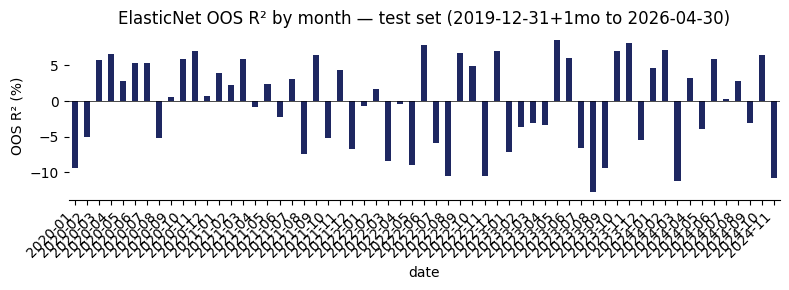

Mean monthly R²:    -0.187%
# months R² > 0:    32 / 59


In [51]:
monthly_r2 = (
    test_df.groupby("date")
           .apply(lambda d: oos_r2_zero_benchmark(d["y"].values, d["y_pred"].values))
           .rename("oos_r2")
)

fig, ax = plt.subplots(figsize=(8, 3))
(monthly_r2 * 100).plot(kind="bar", ax=ax, color="#1E2761")
ax.axhline(0, color="black", linewidth=0.5)
ax.set_ylabel("OOS R² (%)")
ax.set_title(f"{chosen_name} OOS R² by month — test set ({VAL_END}+1mo to {DATA_END})")
ax.set_xticklabels([d.strftime("%Y-%m") for d in monthly_r2.index], rotation=45, ha="right")
plt.tight_layout()
plt.show()

print(f"Mean monthly R²:    {monthly_r2.mean()*100:.3f}%")
print(f"# months R² > 0:    {(monthly_r2 > 0).sum()} / {len(monthly_r2)}")

### 10.3 Coefficient inspection (linear models only)

In [52]:
if hasattr(chosen_model, "coef_"):
    firm_coef_idx = [ALL_COLS.index(c) for c in FEATURE_COLS if c in ALL_COLS]
    coefs = pd.Series(chosen_model.coef_[firm_coef_idx],
                      index=[ALL_COLS[i] for i in firm_coef_idx])
    sign_check = pd.DataFrame({
        "coef":     coefs.round(5),
        "expected": pd.Series({k: v["expected_sign"] for k, v in FEATURE_DICT.items()}),
    })
    sign_check["actual"] = np.where(sign_check["coef"] > 0, "+",
                           np.where(sign_check["coef"] < 0, "\u2212", "0"))
    sign_check["match"] = (
        (sign_check["actual"] == sign_check["expected"])
        | (sign_check["expected"] == "?")
    )
    print(f"{chosen_name} coefficients (firm chars only) — sign-checked vs FEATURE_DICT:")
    print(sign_check)
elif hasattr(chosen_model, "feature_importances_"):
    imp = pd.Series(chosen_model.feature_importances_, index=ALL_COLS)
    print(f"{chosen_name} top-15 feature importances:")
    print(imp.sort_values(ascending=False).head(15).round(4))
else:
    print(f"{chosen_name} has no .coef_ or .feature_importances_ attribute.")

ElasticNet coefficients (firm chars only) — sign-checked vs FEATURE_DICT:
           coef expected actual  match
size        0.0        −      0  False
mom_1       0.0        −      0  False
mom_12_2    0.0        +      0  False
mom_36_13   0.0        −      0  False
vol_12      0.0        −      0  False
turnover    0.0        −      0  False
mom_6_2     0.0        +      0  False
maxret      0.0        −      0  False
nsi         0.0        −      0  False
beta        0.0        −      0  False
age         0.0        −      0  False
bm          0.0        +      0  False
ep          0.0        +      0  False
profit      0.0        +      0  False
leverage    0.0        ?      0   True
invest      0.0        −      0  False
ind_mom     0.0        +      0  False


### 10.4 Factor decomposition of ML predictions

For each portfolio stock, regress the time series of ML predictions on factor returns:

$$\hat{r}_{i,t+1} - r_{f,t+1} = \alpha_i + \beta_i \, \text{Mkt-RF}_{t+1} + \varepsilon_{i,t+1} \quad \text{(CAPM)}$$

$$\hat{r}_{i,t+1} - r_{f,t+1} = \alpha_i + \beta_{mkt,i} \, \text{Mkt-RF}_{t+1} + \beta_{smb,i} \, \text{SMB}_{t+1} + \beta_{hml,i} \, \text{HML}_{t+1} + \beta_{rmw,i} \, \text{RMW}_{t+1} + \beta_{cma,i} \, \text{CMA}_{t+1} + \varepsilon_{i,t+1} \quad \text{(FF5)}$$

$\beta$ is the implicit factor exposure the model is assigning; $\alpha$ is the model's predicted abnormal return.

In [53]:
test_with_factors = merge_with_factors(test_df, ff5)

decomp_rows = []
for ticker in portfolio.values():
    stock_data = (
        test_with_factors[test_with_factors["ticker"] == ticker]
          .sort_values("date")
          .dropna(subset=["Mkt-RF"])
    )
    if len(stock_data) < 6:
        decomp_rows.append({"ticker": ticker, "n_months": len(stock_data), "note": "insufficient data"})
        continue
    capm = fit_capm(stock_data["y_pred"].reset_index(drop=True),
                    stock_data["Mkt-RF"].reset_index(drop=True))
    ff5_res = fit_ff5(stock_data["y_pred"].reset_index(drop=True),
                      stock_data[["Mkt-RF", "SMB", "HML", "RMW", "CMA"]].reset_index(drop=True))
    decomp_rows.append({
        "company":    ticker_to_name[ticker],
        "ticker":     ticker,
        "n_months":   len(stock_data),
        "capm_alpha": capm["alpha"],
        "capm_beta":  capm["beta"],
        "capm_R2":    capm["r2"],
        "ff5_alpha":  ff5_res["alpha"],
        "ff5_b_mkt":  ff5_res["betas"]["Mkt-RF"],
        "ff5_b_smb":  ff5_res["betas"]["SMB"],
        "ff5_b_hml":  ff5_res["betas"]["HML"],
        "ff5_b_rmw":  ff5_res["betas"]["RMW"],
        "ff5_b_cma":  ff5_res["betas"]["CMA"],
        "ff5_R2":     ff5_res["r2"],
    })

decomp_ml = pd.DataFrame(decomp_rows).set_index("ticker")
print(f"Factor decomposition of {chosen_name} predictions:\n")
decomp_ml.round(4)

Factor decomposition of ElasticNet predictions:



,company,n_months,capm_alpha,capm_beta,capm_R2,ff5_alpha,ff5_b_mkt,ff5_b_smb,ff5_b_hml,ff5_b_rmw,ff5_b_cma,ff5_R2
ticker,,,,,,,,,,,,
AAPL,Apple,59,0.0078,-0.0,0.0,0.0078,0.0,0.0,0.0,-0.0,0.0,-3.1949
JPM,JPMorgan Chase,59,0.0078,-0.0,0.0,0.0078,0.0,0.0,0.0,-0.0,0.0,-3.1949
XOM,Exxon Mobil,59,0.0078,-0.0,0.0,0.0078,0.0,0.0,0.0,-0.0,0.0,-3.1949
JNJ,Johnson & Johnson,59,0.0078,-0.0,0.0,0.0078,0.0,0.0,0.0,-0.0,0.0,-3.1949
PG,Procter & Gamble,59,0.0078,-0.0,0.0,0.0078,0.0,0.0,0.0,-0.0,0.0,-3.1949


### 10.5 Compare with realized-return factor decomposition

In [54]:
decomp_rows_real = []
for ticker in portfolio.values():
    stock_data = (
        test_with_factors[test_with_factors["ticker"] == ticker]
          .sort_values("date")
          .dropna(subset=["Mkt-RF"])
    )
    if len(stock_data) < 6:
        continue
    capm = fit_capm(stock_data["y"].reset_index(drop=True),
                    stock_data["Mkt-RF"].reset_index(drop=True))
    ff5_res = fit_ff5(stock_data["y"].reset_index(drop=True),
                      stock_data[["Mkt-RF", "SMB", "HML", "RMW", "CMA"]].reset_index(drop=True))
    decomp_rows_real.append({
        "company":    ticker_to_name[ticker],
        "ticker":     ticker,
        "capm_alpha": capm["alpha"],
        "capm_beta":  capm["beta"],
        "capm_R2":    capm["r2"],
        "ff5_alpha":  ff5_res["alpha"],
        "ff5_b_mkt":  ff5_res["betas"]["Mkt-RF"],
        "ff5_R2":     ff5_res["r2"],
    })

if decomp_rows_real:
    decomp_real = pd.DataFrame(decomp_rows_real).set_index("ticker")
    print("Factor decomposition of REALIZED returns:\n")
    print(decomp_real.round(4))
else:
    print("No stocks have ≥6 months of test data — extend DATA_END or check date alignment.")

Factor decomposition of REALIZED returns:

                  company  capm_alpha  capm_beta  capm_R2  ff5_alpha  ff5_b_mkt  ff5_R2
ticker                                                                                 
AAPL                Apple      0.0236    -0.1367   0.0078     0.0218    -0.2835  0.1007
JPM        JPMorgan Chase      0.0143    -0.0604   0.0017     0.0156    -0.1190  0.0163
XOM           Exxon Mobil      0.0208    -0.4039   0.0503     0.0203    -0.4276  0.1174
JNJ     Johnson & Johnson      0.0023    -0.1007   0.0117     0.0013    -0.0757  0.0826
PG       Procter & Gamble      0.0061     0.0276   0.0008     0.0043    -0.0148  0.0322


---

## 11. Export artifacts for the web app

Saves the trained production model + key dataframes into a single pickle file. The Streamlit app (`app.py`) loads this at startup so it can serve forecasts/optimizations instantly — no WRDS pulls, no retraining at app launch.

**Run order:** after §9 finishes. Then in a terminal: `streamlit run app.py`.

In [55]:
import joblib

# Latest feature snapshot — one row per ticker, most recent date in universe
latest_features_export = (
    features[features["in_universe"]]
      .sort_values(["ticker", "date"])
      .groupby("ticker")
      .tail(1)
      [["ticker", "permno", "comnam", "date"] + ALL_COLS]
      .reset_index(drop=True)
)

# Full rolling-backtest predictions for the chosen model (used by app's
# dynamic Backtest tab). One row per (date, permno) in the OOS test window.
rolling_preds_chosen = rolling_results[chosen_name][["date", "permno", "ticker", "y", "y_pred"]].copy()

artifacts = {
    "chosen_name":         chosen_name,
    "model_prod":          model_prod,          # kept for backward compat
    "models_prod":         models_prod,         # NEW: all three production models
    "all_cols":            ALL_COLS,
    "feature_cols":        FEATURE_COLS,
    "latest_features":     latest_features_export,
    "rolling_predictions": rolling_preds_chosen,
    "comparison_single":   comparison,
    "rolling_summary":     rolling_summary,
    "yearly_r2":           yearly,
    "backtest":            bt_df,
    "backtest_stats":      stats,
    "demo_portfolio":      portfolio,
    "data_start":          DATA_START,
    "data_end":            DATA_END,
}

art_path = CONFIG.cache_dir / "app_artifacts.pkl"
art_path.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(artifacts, art_path)

import os
size_mb = os.path.getsize(art_path) / (1024 * 1024)
print(f"Saved {art_path}  ({size_mb:.1f} MB)")
print(f"  models_prod:         {list(models_prod.keys())}")
print(f"  Rolling predictions: {len(rolling_preds_chosen):,} rows")
print(f"  Latest features:     {len(latest_features_export):,} rows × {len(ALL_COLS)} features")
print(f"\nNow run, from the project folder:")
print(f"   streamlit run app.py")


Saved cache/app_artifacts.pkl  (16.5 MB)
  models_prod:         ['ElasticNet', 'Ridge', 'XGBoost']
  Rolling predictions: 297,895 rows
  Latest features:     5,943 rows × 105 features

Now run, from the project folder:
   streamlit run app.py
